In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [ ]:
dataset = pd.read_csv('/content/train.csv')

In [ ]:
dataset.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
dataset.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
dataset.drop('Name', axis = 1, inplace = True)

In [ ]:
dataset.Cabin.value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [ ]:
dataset.drop('Cabin', axis = 1, inplace = True)

In [ ]:
dataset.drop('Ticket', axis = 1, inplace = True)

In [ ]:
dataset

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [ ]:
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')

In [ ]:
dataset.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
passengerID = dataset.PassengerId

In [ ]:
dataset.drop('PassengerId', axis = 1, inplace = True)

In [ ]:
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
dataset.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
one_hot_cols = ['Sex']
ordinal_encode_cols = ['Embarked']
Embarked_order = ['S', 'C', 'Q']
num_cols = ['Age']
category_cols = ['Embarked']

In [ ]:
ct1 = ColumnTransformer(transformers=[
    ('num_impute', SimpleImputer(strategy = 'mean'), num_cols),
    ('category_impute', SimpleImputer(strategy= 'most_frequent'), category_cols)
], remainder = 'passthrough')

ct2 = ColumnTransformer(transformers=[
    ('one_hot_encoding', OneHotEncoder(drop= 'if_binary'), one_hot_cols),
    ('ordinal_encoding', OrdinalEncoder(categories = [Embarked_order]), ordinal_encode_cols)
], remainder = 'passthrough')

In [ ]:
encoded_array = ct1.fit_transform(dataset)

In [ ]:
raw_col_names = ct1.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_col_names]

In [ ]:
nonulldataset = pd.DataFrame(encoded_array, columns= cols)

In [ ]:
nonulldataset.isna().sum()

,0
Age,0
Embarked,0
Survived,0
Pclass,0
Sex,0
SibSp,0
Parch,0
Fare,0


In [ ]:
encoded_array = ct2.fit_transform(nonulldataset)

In [ ]:
raw_col_names = ct2.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_col_names]

In [ ]:
new_dataset = pd.DataFrame(encoded_array, columns= cols)

In [ ]:
new_dataset

,Sex_male,Embarked,Age,Survived,Pclass,SibSp,Parch,Fare
0,1.0,0.0,22.0,0,3,1,0,7.25
1,0.0,1.0,38.0,1,1,1,0,71.2833
2,0.0,0.0,26.0,1,3,0,0,7.925
3,0.0,0.0,35.0,1,1,1,0,53.1
4,1.0,0.0,35.0,0,3,0,0,8.05
...,...,...,...,...,...,...,...,...
886,1.0,0.0,27.0,0,2,0,0,13.0
887,0.0,0.0,19.0,1,1,0,0,30.0
888,0.0,0.0,29.699118,0,3,1,2,23.45
889,1.0,1.0,26.0,1,1,0,0,30.0


In [ ]:
df = new_dataset

<Axes: >

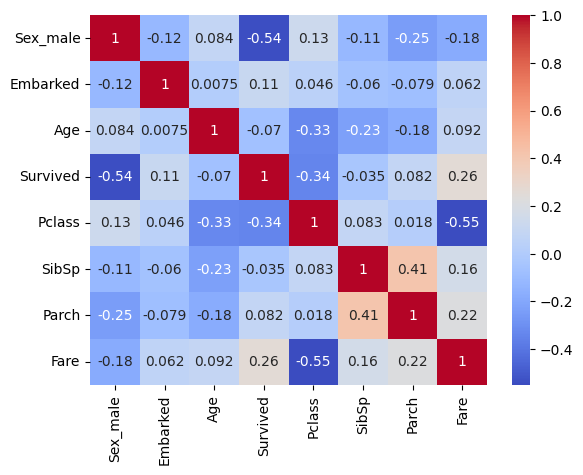

In [ ]:
sns.heatmap(df.corr(), cmap = 'coolwarm', cbar = True, annot = True)

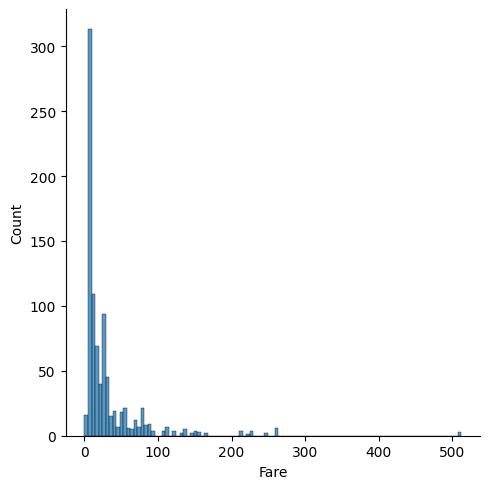

In [ ]:
sns.displot(x = df.Fare)

<Axes: xlabel='Fare'>

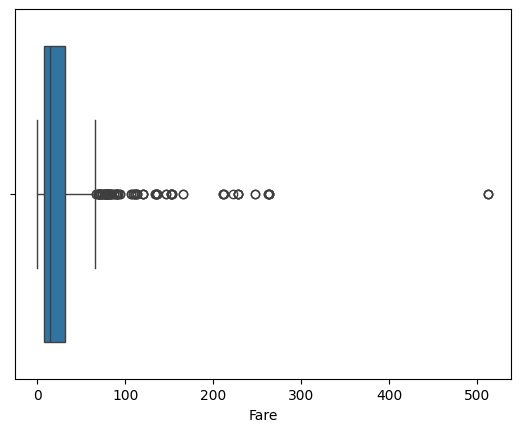

In [ ]:
sns.boxplot(x = df.Fare)

In [ ]:
another_df = df[df['Fare'] < 100]

<Axes: xlabel='Fare'>

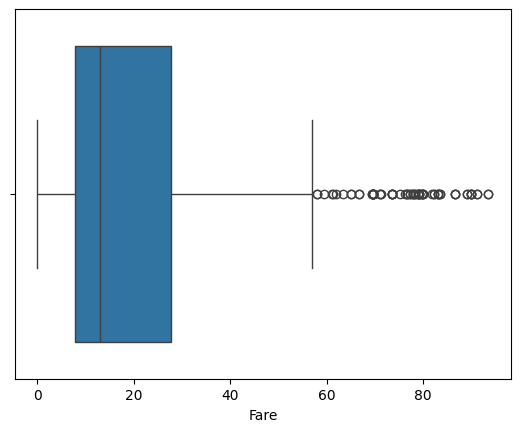

In [ ]:
sns.boxplot(x = another_df.Fare)

In [ ]:
print(df.shape, another_df.shape)

(891, 8) (838, 8)


<Axes: >

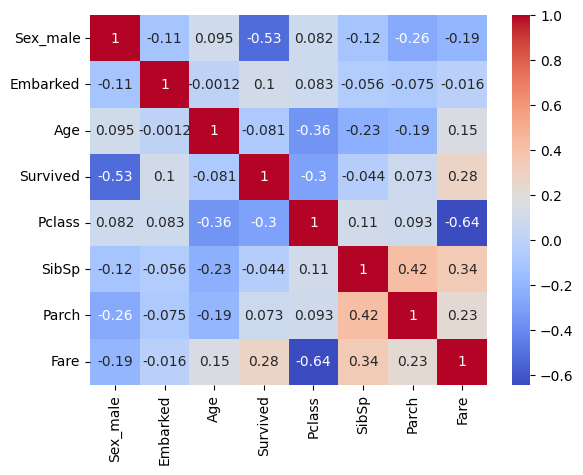

In [ ]:
sns.heatmap(another_df.corr(), cmap = 'coolwarm', cbar = True, annot = True)

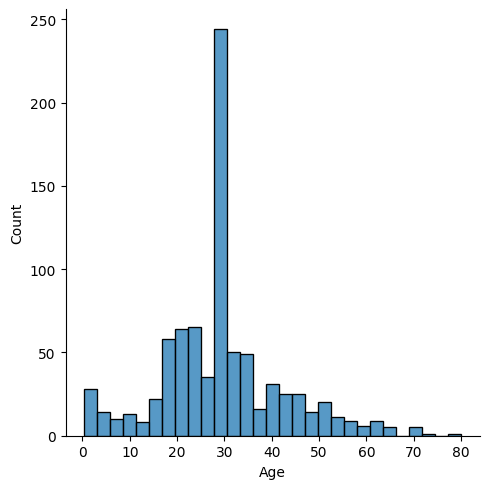

In [ ]:
sns.displot(x = another_df['Age'])`

<Axes: xlabel='Survived', ylabel='Fare'>

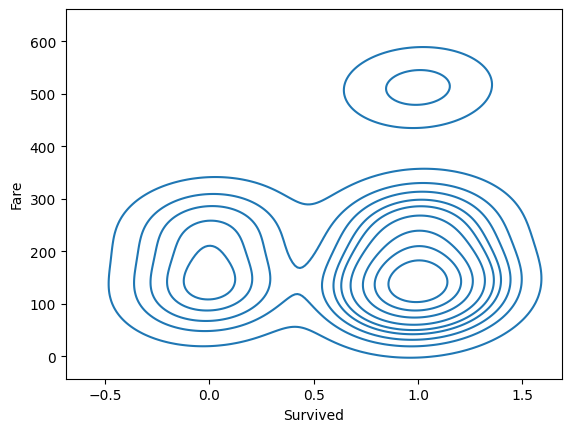

In [ ]:
test_df = df[df.Fare > 100]
sns.kdeplot(x = test_df.Survived, y = test_df.Fare)

In [ ]:
x = df.drop('Survived', axis = 1)
y = df.Survived

In [ ]:
y = y.astype(int)

In [ ]:
models = [
    ('logisticreg', LogisticRegression()),
    ('RandomForest', RandomForestClassifier()),
    ('DecisionTree', DecisionTreeClassifier()),
    ('xgbregressor', XGBClassifier()),
    ('GradientBoost', GradientBoostingClassifier())
]

In [ ]:
results = []
kf = KFold(n_splits=10, shuffle = True, random_state = 43)

for name, model in models:
  training_model = Pipeline(steps=[
      ('scalar', StandardScaler()),
      (name, model)
  ])

  scores = cross_val_score(training_model, x, y, cv = kf)

  results.append({
      'Model_name' : name,
      'Mean_accuracy' : scores.mean(),
      'std dev' : scores.std()
  })

result_df = pd.DataFrame(results)

In [ ]:
result_df.sort_values(by = 'Mean_accuracy', ascending = False)

,Model_name,Mean_accuracy,std dev
4,GradientBoost,0.812634,0.043743
3,xgbregressor,0.805855,0.035070
1,RandomForest,0.798015,0.039986
0,logisticreg,0.794669,0.042304
2,DecisionTree,0.766592,0.034441


In [ ]:
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.08, random_state = 43)

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, stratify = y, test_size = 0.2, random_state = 43)

In [ ]:
model.fit(xtrain, ytrain)

GradientBoostingClassifier(learning_rate=0.08, n_estimators=50, random_state=43)

In [ ]:
ypreds = model.predict(xtest)
accuracy = accuracy_score(ypreds, ytest)

In [ ]:
print('accuracy of the model is: ', accuracy)

accuracy of the model is:  0.8435754189944135


In [ ]:
final_model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.08, random_state = 43)

In [ ]:
final_model.fit(x, y)

GradientBoostingClassifier(learning_rate=0.08, n_estimators=50, random_state=43)

In [ ]:
test_dataset = pd.read_csv('/content/test.csv')

In [ ]:
test_dataset

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
df

,Sex_male,Embarked,Age,Survived,Pclass,SibSp,Parch,Fare
0,1.0,0.0,22.0,0,3,1,0,7.25
1,0.0,1.0,38.0,1,1,1,0,71.2833
2,0.0,0.0,26.0,1,3,0,0,7.925
3,0.0,0.0,35.0,1,1,1,0,53.1
4,1.0,0.0,35.0,0,3,0,0,8.05
...,...,...,...,...,...,...,...,...
886,1.0,0.0,27.0,0,2,0,0,13.0
887,0.0,0.0,19.0,1,1,0,0,30.0
888,0.0,0.0,29.699118,0,3,1,2,23.45
889,1.0,1.0,26.0,1,1,0,0,30.0


In [ ]:
passengerID = test_dataset.PassengerId

In [ ]:
test_dataset.drop(['PassengerId', 'Name', 'Cabin','Ticket'], axis = 1, inplace = True)

In [ ]:
test_dataset

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


In [ ]:
encoded_array = ct1.fit_transform(test_dataset)

In [ ]:
raw_col_names = ct1.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_col_names]

In [ ]:
changed_df = pd.DataFrame(encoded_array, columns = cols)
changed_df

,Age,Embarked,Pclass,Sex,SibSp,Parch,Fare
0,34.5,Q,3,male,0,0,7.8292
1,47.0,S,3,female,1,0,7.0
2,62.0,Q,2,male,0,0,9.6875
3,27.0,S,3,male,0,0,8.6625
4,22.0,S,3,female,1,1,12.2875
...,...,...,...,...,...,...,...
413,30.27259,S,3,male,0,0,8.05
414,39.0,C,1,female,0,0,108.9
415,38.5,S,3,male,0,0,7.25
416,30.27259,S,3,male,0,0,8.05


In [ ]:
encoded_array = ct2.fit_transform(changed_df)


In [ ]:
raw_col_names = ct2.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_col_names]

In [ ]:
new_test_df = pd.DataFrame(encoded_array, columns = cols)
new_test_df

,Sex_male,Embarked,Age,Pclass,SibSp,Parch,Fare
0,1.0,2.0,34.5,3,0,0,7.8292
1,0.0,0.0,47.0,3,1,0,7.0
2,1.0,2.0,62.0,2,0,0,9.6875
3,1.0,0.0,27.0,3,0,0,8.6625
4,0.0,0.0,22.0,3,1,1,12.2875
...,...,...,...,...,...,...,...
413,1.0,0.0,30.27259,3,0,0,8.05
414,0.0,1.0,39.0,1,0,0,108.9
415,1.0,0.0,38.5,3,0,0,7.25
416,1.0,0.0,30.27259,3,0,0,8.05


In [ ]:
x

,Sex_male,Embarked,Age,Pclass,SibSp,Parch,Fare
0,1.0,0.0,22.0,3,1,0,7.25
1,0.0,1.0,38.0,1,1,0,71.2833
2,0.0,0.0,26.0,3,0,0,7.925
3,0.0,0.0,35.0,1,1,0,53.1
4,1.0,0.0,35.0,3,0,0,8.05
...,...,...,...,...,...,...,...
886,1.0,0.0,27.0,2,0,0,13.0
887,0.0,0.0,19.0,1,0,0,30.0
888,0.0,0.0,29.699118,3,1,2,23.45
889,1.0,1.0,26.0,1,0,0,30.0


In [ ]:
median_fare = float(new_test_df.Fare.median())
new_test_df.Fare.fillna(median_fare, inplace = True)


/tmp/ipython-input-2387013007.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_test_df.Fare.fillna(median_fare, inplace = True)
/tmp/ipython-input-2387013007.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_test_df.Fare.fillna(median_fare, inplace = True)


In [ ]:
new_test_df.isna().sum()

,0
Sex_male,0
Embarked,0
Age,0
Pclass,0
SibSp,0
Parch,0
Fare,0


In [ ]:
ypreds = final_model.predict(new_test_df)

In [245]:
ypreds.shape

(418,)

In [ ]:
submission = pd.DataFrame({
    "PassengerId": passengerID,
    "Survived": ypreds
})

In [ ]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
submission.to_csv('submission.csv', index = False)